# NZ Road Crash ML - EDA

## Load Libraries and Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [12]:
# Set Seaborn theme and context for better aesthetics
sns.set_theme(style="white")
sns.set_context("notebook", font_scale=1.1)
sns.despine()
%config InlineBackend.figure_format = 'retina'

<Figure size 640x480 with 0 Axes>

In [2]:
df = pd.read_csv('data/Crash_Analysis_System__CAS__data.csv')
df.head()

,X,Y,OBJECTID,advisorySpeed,areaUnitID,bicycle,bridge,bus,carStationWagon,cliffBank,...,train,tree,truck,unknownVehicleType,urban,vanOrUtility,vehicle,waterRiver,weatherA,weatherB
0,1747565.0,5427642.0,1,NaN,575300.0,0.0,NaN,0.0,2.0,NaN,...,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Fine,Null
1,1544693.0,5170620.0,2,NaN,587020.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,Open,0.0,0.0,0.0,Fine,Null
2,1615685.0,5423963.0,3,NaN,584201.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,Urban,0.0,0.0,0.0,Fine,Null
3,1799588.0,5821916.0,4,NaN,527007.0,0.0,NaN,0.0,2.0,NaN,...,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Fine,Null
4,1570549.0,5176071.0,5,NaN,591101.0,1.0,NaN,0.0,0.0,NaN,...,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Fine,Null


## Inspect the target

In [10]:
df['crashSeverity'].value_counts(normalize=True).round(2)*100

crashSeverity
Non-Injury Crash    70.0
Minor Crash         23.0
Serious Crash        6.0
Fatal Crash          1.0
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Distribution of Crash Severity')

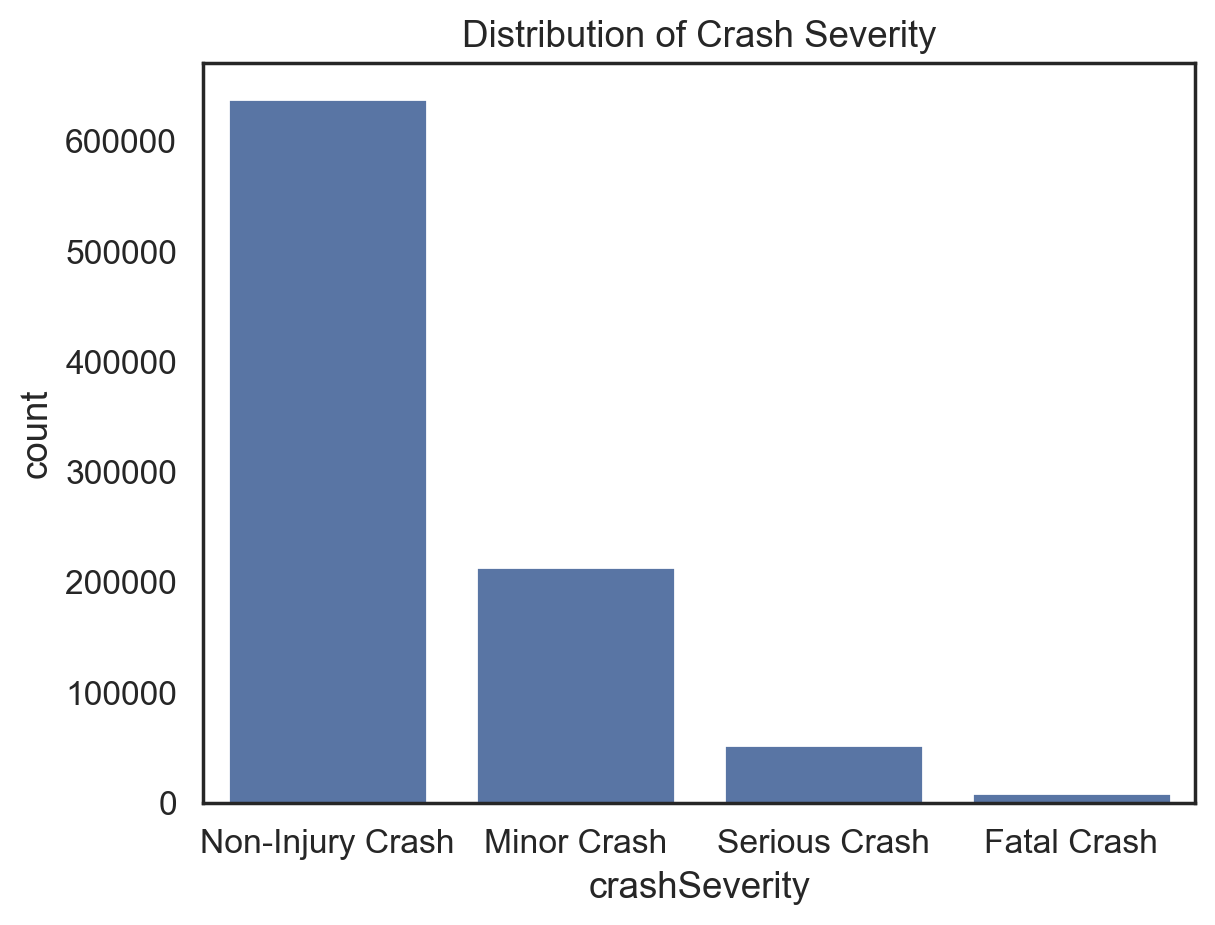

In [14]:
sns.countplot(x='crashSeverity', data=df, order=df['crashSeverity'].value_counts().index)
plt.title('Distribution of Crash Severity')

As we can see our target suffers from class imbalance with Fatal Crash only being 1% of the whole dataset. The majority class being Non-Injury Crash with 69% of the total crashes. 
It is importance to note that a baseline model which always predicts a crash being Non-Injury will have an average of 69% accuracy. 
So there are key considerations when building the classifier model: 
- The evaluation metric used to deal with class imbalance.
- Comparision with the baseline model.
- Techniques to deal with class imbalance: class weighting, resampling, or class-conditional thresholds.

## Inspect the features

### Remove Unnecessary Features

In [15]:
df.columns

Index(['X', 'Y', 'OBJECTID', 'advisorySpeed', 'areaUnitID', 'bicycle',
       'bridge', 'bus', 'carStationWagon', 'cliffBank',
       'crashDirectionDescription', 'crashFinancialYear', 'crashLocation1',
       'crashLocation2', 'crashRoadSideRoad', 'crashSeverity',
       'crashSHDescription', 'crashYear', 'debris', 'directionRoleDescription',
       'ditch', 'fatalCount', 'fence', 'flatHill', 'guardRail', 'holiday',
       'houseOrBuilding', 'intersection', 'kerb', 'light', 'meshblockId',
       'minorInjuryCount', 'moped', 'motorcycle', 'NumberOfLanes',
       'objectThrownOrDropped', 'otherObject', 'otherVehicleType', 'overBank',
       'parkedVehicle', 'pedestrian', 'phoneBoxEtc', 'postOrPole', 'region',
       'roadCharacter', 'roadLane', 'roadSurface', 'roadworks', 'schoolBus',
       'seriousInjuryCount', 'slipOrFlood', 'speedLimit', 'strayAnimal',
       'streetLight', 'suv', 'taxi', 'temporarySpeedLimit', 'tlaId', 'tlaName',
       'trafficControl', 'trafficIsland', 'trafficSi

Strategies to select features for the model:
- Remove features that are too sparse. (>90% null)
- Remove features that will lead to target leakage. (unknow at the time of prediction or direct indicate of target)
- Remove identifier and free text (IDs, X, Y coordinate, locations (street))

In [27]:
missing_count = df.isnull().sum().sort_values(ascending=False).to_frame(name='missing_count')
missing_count['missing_percentage'] = (missing_count['missing_count'] / len(df) * 100).round(2)
missing_count[missing_count['missing_percentage'] > 90]

,missing_count,missing_percentage
intersection,913464,100.00
crashRoadSideRoad,913464,100.00
temporarySpeedLimit,897788,98.28
pedestrian,883236,96.69
advisorySpeed,877345,96.05
holiday,863013,94.48


In [28]:
df['holiday'].value_counts()

holiday
Christmas New Year    23447
Easter                10408
Queens Birthday        8722
Labour Weekend         7874
Name: count, dtype: int64

Based on the missing percentage we will drop `intersection`, `crashRoadSideRoad`, `temporarySpeedLimit`, `pedestrian`, `advisorySpeed` as they have > 90% Nulls. In the case of `holiday` after checking on the field description we learned that Nulls indicates it's a normal day. So we will impute with 'Normal Day' and use that as a feature.

In [32]:
df.drop(columns=missing_count.head(5).index, inplace=True)

In [33]:
df['holiday'] = df['holiday'].fillna('Normal Day')

In [36]:
df['holiday'].value_counts(normalize=True).round(2)*100

holiday
Normal Day            94.0
Christmas New Year     3.0
Easter                 1.0
Queens Birthday        1.0
Labour Weekend         1.0
Name: proportion, dtype: float64

Now we will drop the features that lead to target leakage.

In [38]:
columns_to_drop =df.filter(regex='.*Count$').columns
columns_to_drop

Index(['fatalCount', 'minorInjuryCount', 'seriousInjuryCount'], dtype='str')

In [40]:
df.drop(columns=columns_to_drop, inplace=True)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 913464 entries, 0 to 913463
Data columns (total 64 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   X                          913464 non-null  float64
 1   Y                          913464 non-null  float64
 2   OBJECTID                   913464 non-null  int64  
 3   areaUnitID                 913460 non-null  float64
 4   bicycle                    913459 non-null  float64
 5   bridge                     376691 non-null  float64
 6   bus                        913459 non-null  float64
 7   carStationWagon            913459 non-null  float64
 8   cliffBank                  376691 non-null  float64
 9   crashDirectionDescription  913464 non-null  str    
 10  crashFinancialYear         913464 non-null  str    
 11  crashLocation1             913464 non-null  str    
 12  crashLocation2             911557 non-null  str    
 13  crashSeverity              913464 non-nu

In [53]:
columns_to_drop = df.columns[df.columns.str.lower().str.endswith('id')]
columns_to_drop

Index(['OBJECTID', 'areaUnitID', 'meshblockId', 'tlaId'], dtype='str')

In [54]:
df.drop(columns=columns_to_drop, inplace=True)

In [55]:
df.drop(columns=['X', 'Y', 'crashLocation1', 'crashLocation2', 'crashFinancialYear'], inplace=True)

Now that we have 55 columns left.
We will also remove `tlaName` (67 distinct values) as we have `region` is a less cardinarity feature.

In [62]:
df.drop('tlaName', axis=1, inplace=True)

### Null Values Imputation